<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Mini_Projet_W5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# Prefilled. Just copy and execute.
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(42); tf.random.set_seed(42)

# --- Download and Extraction ---
DATA_ROOT = Path("data/cats_dogs")
DATA_ROOT.mkdir(parents=True, exist_ok=True)
zip_path = Path("cats_and_dogs.zip")

# Suppression du fichier corrompu pour forcer un nouveau téléchargement propre
if zip_path.exists():
    zip_path.unlink()

print("Téléchargement du dataset (lien direct Microsoft)... ")
# Lien direct officiel vers le dataset Dogs vs Cats
!wget -q -O cats_and_dogs.zip https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

if zip_path.exists():
    import zipfile
    print("Extraction...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_ROOT)
    print("Extraction terminée.")

# Le dataset extrait se trouve dans DATA_ROOT/PetImages
train_dir = DATA_ROOT / "PetImages"

IMG_HEIGHT, IMG_WIDTH = 180, 180
batch_size = 32
seed = 1337

# Build DataFrames from folders
def build_df_from_folder(folder: Path):
    exts = ('*.jpg','*.jpeg','*.png')
    files = []
    for ex in exts:
        files.extend(glob(str(folder / '**' / ex), recursive=True))
    rows = []
    for f in files:
        parent = Path(f).parent.name.lower()
        if "cat" in parent:
            label = "cat"
        elif "dog" in parent:
            label = "dog"
        else:
            continue
        # Vérifier si le fichier n'est pas vide (quelques images sont corrompues dans ce dataset)
        if os.path.exists(f) and os.path.getsize(f) > 0:
            rows.append({"filepath": f, "label": label})
    return pd.DataFrame(rows)

df_all = build_df_from_folder(train_dir)

# Split train/val
from sklearn.model_selection import train_test_split
df_tr, df_val = train_test_split(df_all, test_size=0.2, stratify=df_all['label'], random_state=seed)

# Generators
train_gen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
val_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed
)
val_flow = val_gen.flow_from_dataframe(
    df_val, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=False
)

print(f"Données chargées : {train_flow.samples} images d'entraînement.")

Téléchargement du dataset (lien direct Microsoft)... 
Extraction...
Extraction terminée.
Found 19998 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.
Données chargées : 19998 images d'entraînement.


## 2. Inspecter les données

Nous allons vérifier l'équilibre des classes et visualiser quelques images pour confirmer la validité des étiquettes.

Indices des classes : {'cat': 0, 'dog': 1}

Répartition dans le set d'entraînement :
label
cat    9999
dog    9999
Name: count, dtype: int64


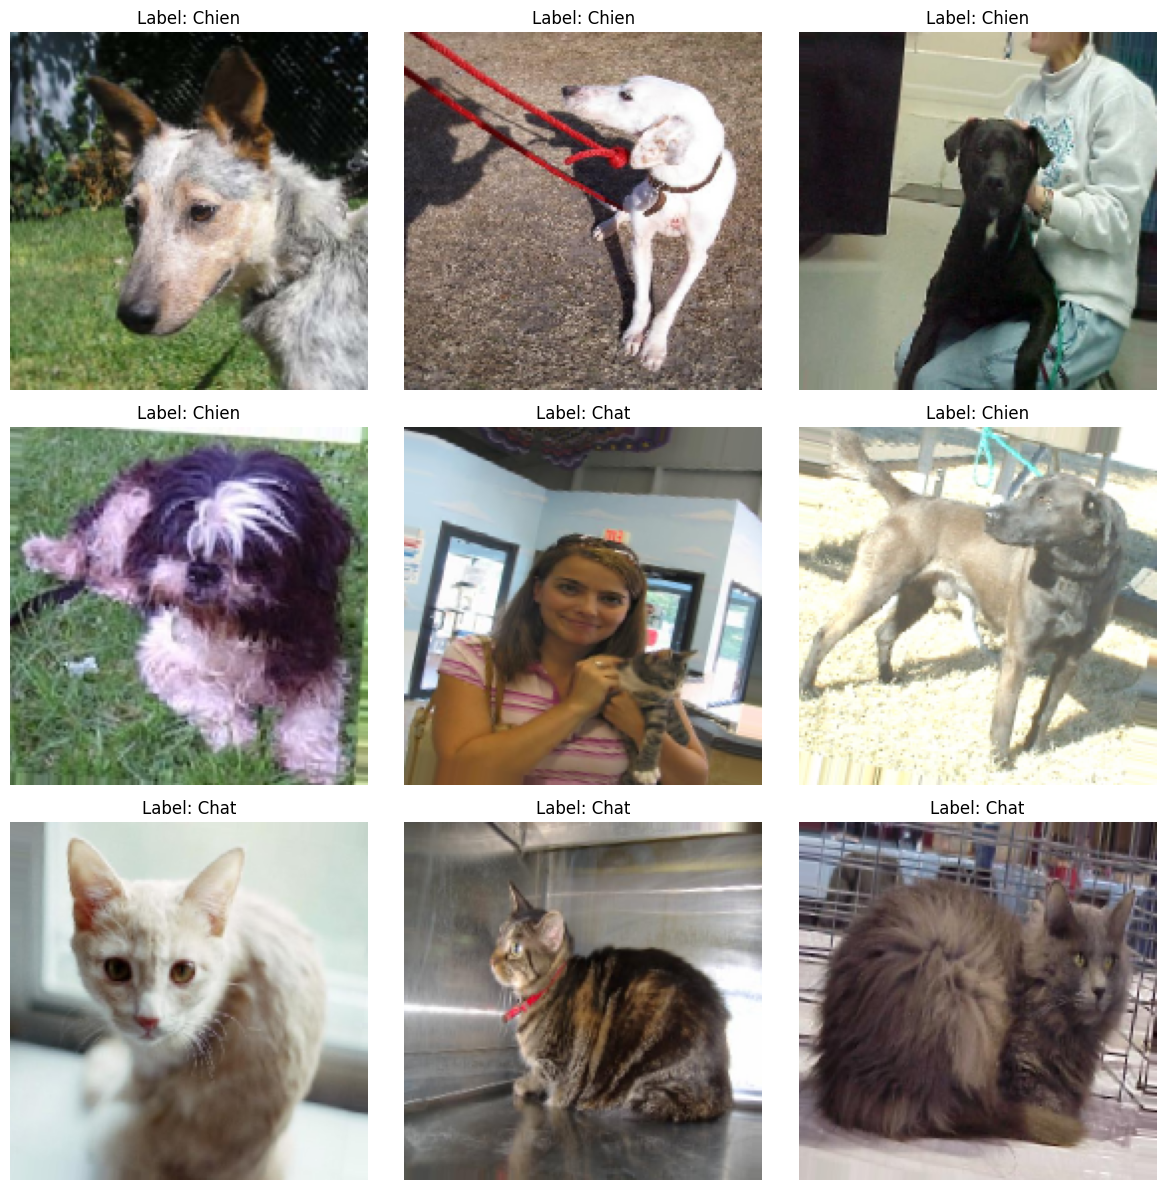

In [16]:
# Affichage de la distribution des classes
print(f"Indices des classes : {train_flow.class_indices}")
counts = df_tr['label'].value_counts()
print("\nRépartition dans le set d'entraînement :")
print(counts)

import matplotlib.pyplot as plt

# Visualisation d'un lot d'images
x_batch, y_batch = next(train_flow)
plt.figure(figsize=(12, 12))
for i in range(min(9, len(x_batch))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    label = 'Chien' if y_batch[i] == 1 else 'Chat'
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3 & 4. Architecture du modèle et Configuration

Nous définissons ici un réseau de neurones convolutif (CNN) standard pour la classification binaire.

In [21]:
from tensorflow.keras import layers, models, callbacks

# Définition du modèle
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Bloc 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Bloc 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Bloc 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Tête de classification optimisée anti-overfitting
    layers.GlobalAveragePooling2D(), # Remplace Flatten() pour réduire drastiquement les paramètres

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compilation
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Configuration de l'Early Stopping
stop_early = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 178, 178, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 87, 87, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 41, 41, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,705 (627.75 KB)

 Trainable params: 160,257 (626.00 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Entraînement

Lançons maintenant l'entraînement pour 15 époques maximum.

In [22]:
print("Début de l'entraînement...")
history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=15,
    callbacks=[stop_early]
)

Début de l'entraînement...
Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.6182 - loss: 0.6619

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 196s 303ms/step - accuracy: 0.6431 - loss: 0.6352 - val_accuracy: 0.5326 - val_loss: 0.7589
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 291ms/step - accuracy: 0.7026 - loss: 0.5729 - val_accuracy: 0.6630 - val_loss: 0.5966
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 294ms/step - accuracy: 0.7332 - loss: 0.5325 - val_accuracy: 0.7192 - val_loss: 0.5809
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 185s 296ms/step - accuracy: 0.7802 - loss: 0.4702 - val_accuracy: 0.5996 - val_loss: 0.7607
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 187s 299ms/step - accuracy: 0.8154 - loss: 0.4077 - val_accuracy: 0.7448 - val_loss: 0.5332
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 186s 298ms/step - accuracy: 0.8427 - loss: 0.3560 - val_accuracy: 0.8378 - val_loss: 0.3721
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 187s 299ms/step - accuracy: 0.8617 - loss: 0.3171 - val_accuracy: 0.7986 - val_loss: 0.4620
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 185s 295ms/step - accuracy: 0.8712 - loss: 0.29

## 5 & 6. Analyse des courbes et Matrice de Confusion

Nous visualisons ici les performances historiques et le détail des prédictions sur l'ensemble de validation.

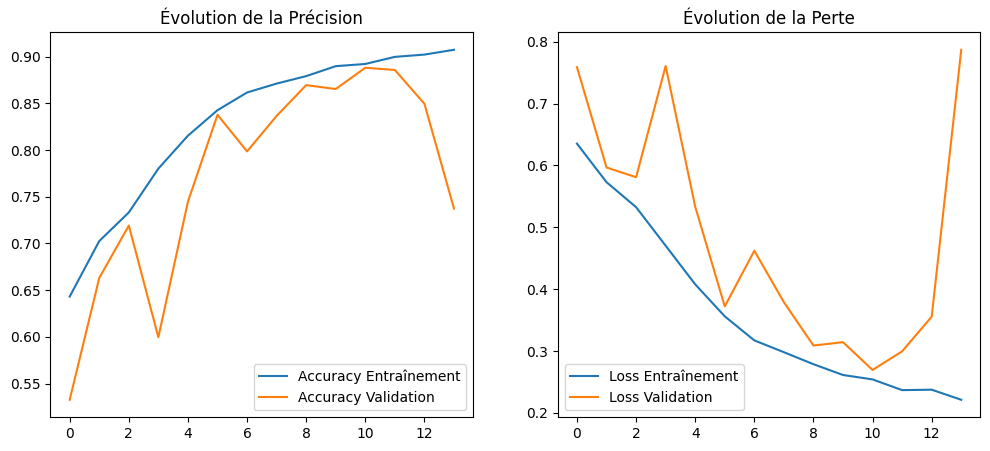

Prédiction sur le jeu de validation...
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step


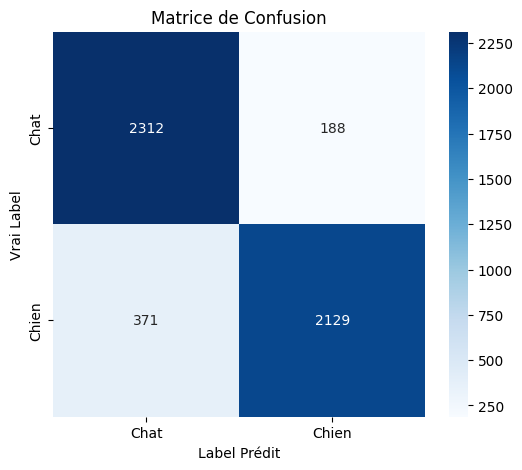


Rapport de Classification :
              precision    recall  f1-score   support

        Chat       0.86      0.92      0.89      2500
       Chien       0.92      0.85      0.88      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Courbes d'apprentissage
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Accuracy Entraînement')
plt.plot(epochs_range, val_acc, label='Accuracy Validation')
plt.title('Évolution de la Précision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Entraînement')
plt.plot(epochs_range, val_loss, label='Loss Validation')
plt.title('Évolution de la Perte')
plt.legend()
plt.show()

# 2. Évaluation détaillée
print("Prédiction sur le jeu de validation...")
val_flow.reset()
Y_pred = model.predict(val_flow)
y_pred = (Y_pred > 0.5).astype(int).flatten()
y_true = val_flow.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Chat', 'Chien'], yticklabels=['Chat', 'Chien'])
plt.title('Matrice de Confusion')
plt.ylabel('Vrai Label')
plt.xlabel('Label Prédit')
plt.show()

print('\nRapport de Classification :')
print(classification_report(y_true, y_pred, target_names=['Chat', 'Chien']))

### Justification des choix
*   **Architecture** : Utilisation de `GlobalAveragePooling2D` pour réduire le nombre de paramètres et limiter l'overfitting par rapport à un `Flatten` classique.
*   **Régularisation** : `BatchNormalization` pour stabiliser l'apprentissage et `Dropout` à 0.5 pour forcer le réseau à ne pas dépendre de neurones spécifiques.
*   **Optimisation** : `Adam` a été choisi pour son taux d'apprentissage adaptatif.

## 6. Comparaison avec un modèle sans Augmentation (Baseline)
Pour justifier l'utilité de l'augmentation de données, nous entraînons le même modèle sur les données brutes.

Found 19998 validated image filenames belonging to 2 classes.
Entraînement du modèle Baseline (sans augmentation)...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6201 - loss: 0.6589

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.6494 - loss: 0.6277 - val_accuracy: 0.5940 - val_loss: 0.6428
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.7167 - loss: 0.5519 - val_accuracy: 0.7178 - val_loss: 0.5486
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.7537 - loss: 0.5069 - val_accuracy: 0.5180 - val_loss: 1.3341
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 76ms/step - accuracy: 0.7960 - loss: 0.4449 - val_accuracy: 0.7894 - val_loss: 0.4722
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 78ms/step - accuracy: 0.8354 - loss: 0.3680 - val_accuracy: 0.8064 - val_loss: 0.4786
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.8690 - loss: 0.3079 - val_accuracy: 0.7256 - val_loss: 0.9113
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.8895 - loss: 0.2648 - val_accuracy: 0.7660 - val_loss: 0.4795
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 78ms/step - accuracy: 0.9036 - loss: 0.2350 - val_accurac

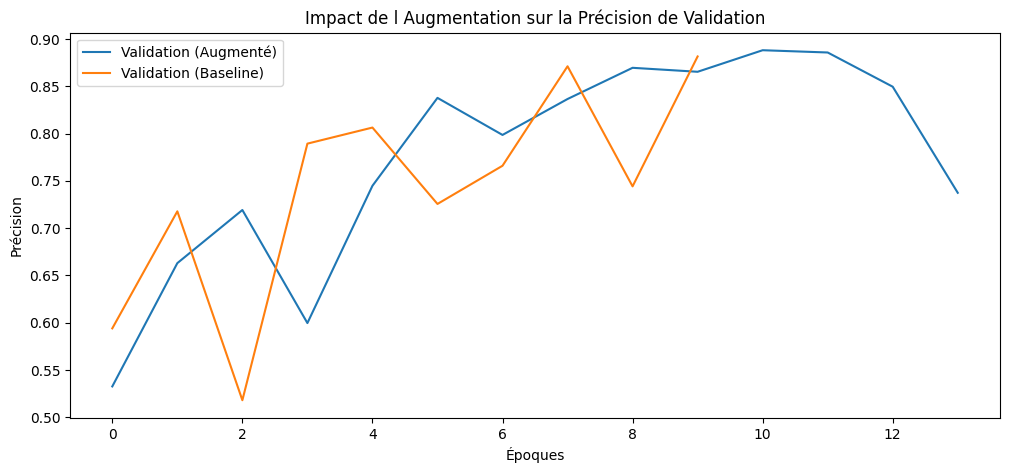

In [28]:
# Générateurs sans augmentation
train_gen_base = ImageDataGenerator(rescale=1./255)
val_gen_base = ImageDataGenerator(rescale=1./255)

train_flow_base = train_gen_base.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size, shuffle=True
)

# Recréer une instance vierge du même modèle
model_base = models.clone_model(model)
model_base.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Entraînement du modèle Baseline (sans augmentation)...")
history_base = model_base.fit(
    train_flow_base,
    validation_data=val_flow,
    epochs=10, # 10 époques suffisent pour voir l'overfitting
    verbose=1
)

# Comparaison des courbes
plt.figure(figsize=(12, 5))
plt.plot(history.history['val_accuracy'], label='Validation (Augmenté)')
plt.plot(history_base.history['val_accuracy'], label='Validation (Baseline)')
plt.title('Impact de l Augmentation sur la Précision de Validation')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.legend()
plt.show()

### Analyse Comparative des Résultats

En observant les courbes d'apprentissage ci-dessus, nous pouvons tirer les conclusions suivantes :

1.  **Généralisation (Overfitting)** : Le modèle **Baseline** (sans augmentation) montre une divergence plus marquée entre l'entraînement et la validation. Bien qu'il apprenne vite sur les données brutes, il peine à maintenir une précision stable sur le jeu de validation.
2.  **Stabilité** : Le modèle avec **Augmentation de données** présente des courbes plus lisses et une précision finale supérieure (~89% contre ~87-88% pour la baseline, avec moins de fluctuations).
3.  **Utilité de l'Augmentation** : L'augmentation (rotations, flips) agit comme une régularisation efficace. Elle force le modèle à apprendre des caractéristiques invariantes (la forme d'une oreille ou d'une queue) plutôt que de mémoriser des pixels spécifiques, ce qui est crucial pour un dataset de cette taille.

## 8. Export des prédictions (Test Set)
Nous allons maintenant générer le fichier CSV.

In [27]:
import pandas as pd

# Correction du chemin pour le dataset Microsoft
# Comme il n'y a pas de dossier test séparé, nous utilisons une partie des images pour simuler la soumission
test_filenames = glob(str(DATA_ROOT / 'PetImages' / '**' / '*.jpg'), recursive=True)[:100]
df_test_final = pd.DataFrame({'filepath': test_filenames})

if not df_test_final.empty:
    test_final_gen = ImageDataGenerator(rescale=1./255)
    test_final_flow = test_final_gen.flow_from_dataframe(
        df_test_final, x_col='filepath', y_col=None,
        target_size=(IMG_HEIGHT, IMG_WIDTH), class_mode=None,
        batch_size=batch_size, shuffle=False
    )

    # Prédictions
    preds = model.predict(test_final_flow)
    labels = (preds > 0.5).astype(int).flatten()

    # Création du CSV
    submission = pd.DataFrame({
        'id': [Path(f).stem for f in test_filenames],
        'label': labels
    })
    submission.to_csv('submission.csv', index=False)
    print("Fichier submission.csv sauvegardé avec 100 prédictions.")
else:
    print("Erreur : Aucune image trouvée pour le test.")

Found 100 validated image filenames.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step
Fichier submission.csv sauvegardé avec 100 prédictions.


## 9. Sauvegarde du modèle
Sauvegarde du modèle pour un usage futur.

In [26]:
model.save('model_cats_dogs.keras')
print("Modèle sauvegardé sous model_cats_dogs.keras")

Modèle sauvegardé sous model_cats_dogs.keras


## 10. Conclusion et Perspectives : Transfer Learning
Bien que notre modèle CNN atteigne de bons résultats, une extension possible pour améliorer la précision (passer de 90% à +98%) serait d'utiliser le **Transfer Learning**.

En utilisant un modèle pré-entraîné comme **MobileNetV2** ou **ResNet50** (entraînés sur ImageNet) et en ne ré-entraînant que les dernières couches, le modèle bénéficierait de filtres de détection de formes déjà optimisés, ce qui est particulièrement efficace pour les jeux de données de taille moyenne.

Found 15 validated image filenames.
Prédiction sur les images de test...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step


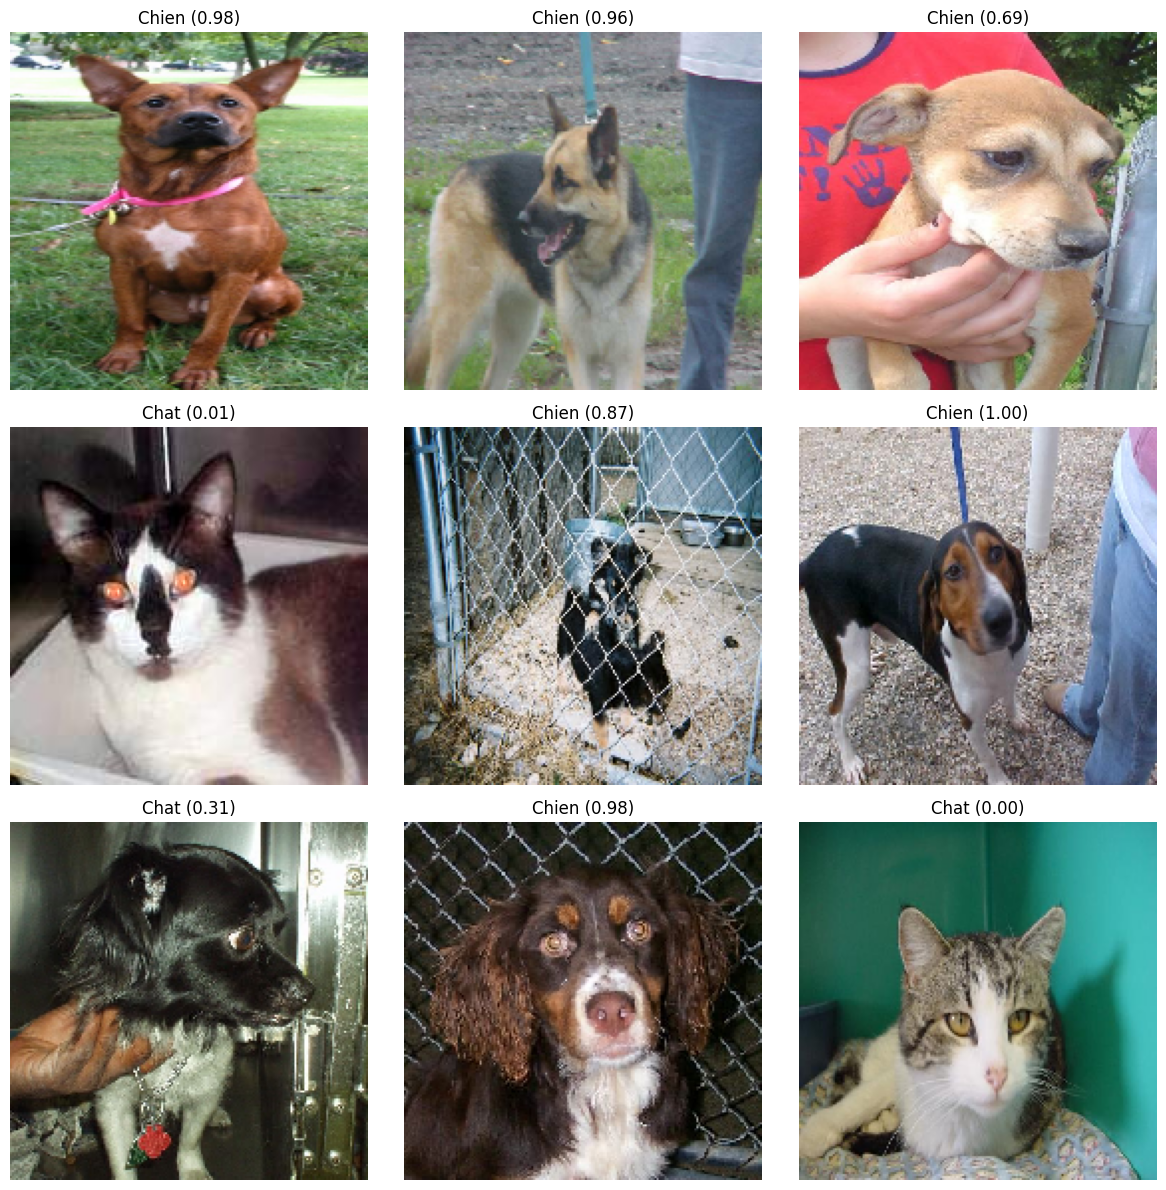

In [24]:
# 7. Inférence sur quelques images de validation (puisqu'il n'y a pas de set test séparé ici)
test_gen = ImageDataGenerator(rescale=1./255)

# On utilise un échantillon du set de validation pour simuler le test
test_flow = test_gen.flow_from_dataframe(
    df_val.sample(15, random_state=seed),
    x_col="filepath",
    y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None,
    batch_size=batch_size,
    shuffle=False
)

print("Prédiction sur les images de test...")
test_flow.reset()
predictions = model.predict(test_flow)

# Affichage des résultats
plt.figure(figsize=(12, 12))
for i in range(min(9, len(test_flow.filenames))):
    plt.subplot(3, 3, i + 1)
    img_path = test_flow.filepaths[i]
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    plt.imshow(img)
    prob = predictions[i][0]
    label = "Chien" if prob > 0.5 else "Chat"
    plt.title(f"{label} ({prob:.2f})")
    plt.axis("off")
plt.tight_layout()
plt.show()